# Install library

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib numpy seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Import library

In [2]:
import glob
import gc
import os
import sys
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models

src_dir = os.path.abspath("../")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from nn.layers.conv import Conv2D, LocallyConnected2D
from nn.layers.dense import Dense
from nn.layers.pool import Flatten, MaxPooling2D, AveragePooling2D
from nn.model import Model
from nn.engine import Tensor
from utility.image_utils import load_batch
from utility.model_loader import load_keras_weights

# Persiapan

In [24]:
BASE_DATA_PATH = "../../data/1_cnn_image_classification"
TEST_PATH = os.path.join(BASE_DATA_PATH, "seg_test", "seg_test")
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

X_test_list = []
y_test_list = []

for images, labels in test_dataset:
    X_test_list.append(images.numpy())
    y_test_list.append(labels.numpy())

X_test = np.vstack(X_test_list).astype(np.float32)
y_test_categorical = np.vstack(y_test_list)
num_classes = len(test_dataset.class_names)
weights_path = os.path.abspath("saved_models/model_14_L3_F64_K3_avg.weights.h5")

print(f"Total data uji keseluruhan: {X_test.shape[0]} gambar.")

np.random.seed(42)
random_indices = np.random.choice(len(X_test), size=32, replace=False)
X_batch = X_test[random_indices] / 255.0
y_batch_mixed = y_test_categorical[random_indices]
y_true = np.argmax(y_batch_mixed, axis=1)

print(f"Total data uji yang dipakai: {X_batch.shape[0]} gambar.")
print("Label asli:", y_true)

Found 3000 files belonging to 6 classes.
Total data uji keseluruhan: 3000 gambar.
Total data uji yang dipakai: 32 gambar.
Label asli: [3 2 3 0 5 2 2 4 0 5 4 0 1 3 5 1 2 1 5 5 0 0 2 4 2 5 5 2 0 2 2 3]


# Shared parameter

## Keras

In [25]:
keras_input = tf.keras.layers.Input(shape=(128, 128, 3))
x = tf.keras.layers.Rescaling(1.0 / 255)(keras_input)
x = tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = tf.keras.layers.AveragePooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = tf.keras.layers.AveragePooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
x = tf.keras.layers.AveragePooling2D((2, 2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
keras_output = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
keras_model_14 = tf.keras.models.Model(inputs=keras_input, outputs=keras_output)

if os.path.exists(weights_path):
    keras_model_14.load_weights(weights_path)
    print("Bobot Keras Eksperimen 14 berhasil dimuat.")
else:
    print(f"Error: File bobot tidak ditemukan di {weights_path}")

Bobot Keras Eksperimen 14 berhasil dimuat.


## From scratch

In [26]:
shared_model = Model()
shared_model.add(Conv2D(output_channels=64, kernel_size=3, padding=1, activation="relu"))
shared_model.add(AveragePooling2D(pool_size=2, stride=2))
shared_model.add(Conv2D(output_channels=128, kernel_size=3, padding=1, activation="relu"))
shared_model.add(AveragePooling2D(pool_size=2, stride=2))
shared_model.add(Conv2D(output_channels=256, kernel_size=3, padding=1, activation="relu"))
shared_model.add(AveragePooling2D(pool_size=2, stride=2))
shared_model.add(Flatten())
shared_model.add(Dense(64, activation="relu"))
shared_model.add(Dense(num_classes, activation="softmax"))

shared_model.build(X_batch.shape)

if os.path.exists(weights_path):
    keras_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(keras_input)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    keras_output = layers.Dense(num_classes, activation="softmax")(x)
    keras_model = models.Model(inputs=keras_input, outputs=keras_output)
    keras_model.load_weights(weights_path)

    load_keras_weights(shared_model, keras_model)

start_time = time.time()
batch_size = 4
outputs_list = []

for i in range(0, len(X_batch), batch_size):
    X_mini = X_batch[i : i + batch_size]
    out_mini = shared_model.forward(X_mini)
    
    arr_data = out_mini.data if hasattr(out_mini, 'data') else out_mini.value
    outputs_list.append(arr_data)

    del out_mini
    gc.collect()

shared_output_data = np.vstack(outputs_list)

shared_duration = time.time() - start_time
print(f"Forward pass selesai dalam {shared_duration:.4f} detik.")


Successfully loaded 10 parameters from Keras model.

Forward pass selesai dalam 111.5621 detik.


## Evaluasi


PERBANDINGAN KERAS VS SCRATCH (SHARED PARAMETER)
Total Parameter Model  : 4,565,574
Macro F1-Score Keras   : 0.7790
Macro F1-Score Scratch : 0.7790

-------------------------------------------------------------------
CLASSIFICATION REPORT
-------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.80      0.67      0.73         6
     Class 1       1.00      1.00      1.00         3
     Class 2       0.86      0.67      0.75         9
     Class 3       0.75      0.75      0.75         4
     Class 4       0.50      0.67      0.57         3
     Class 5       0.78      1.00      0.88         7

    accuracy                           0.78        32
   macro avg       0.78      0.79      0.78        32
weighted avg       0.80      0.78      0.78        32

              precision    recall  f1-score   support

     Class 0       0.80      0.67      0.73         6
     Class 1       1.00      1.00      1

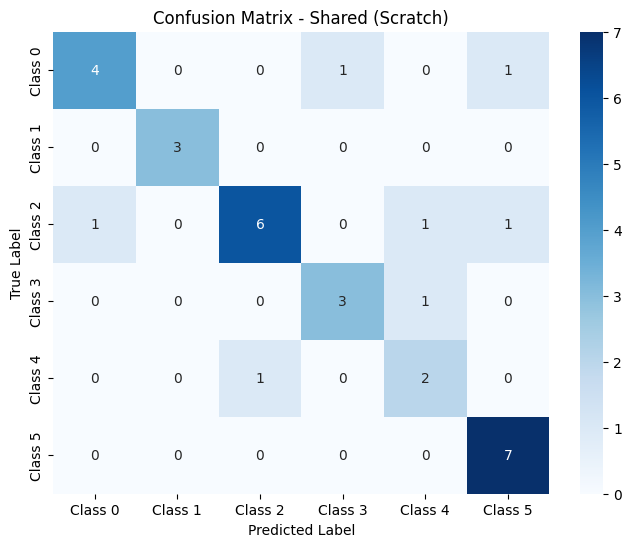

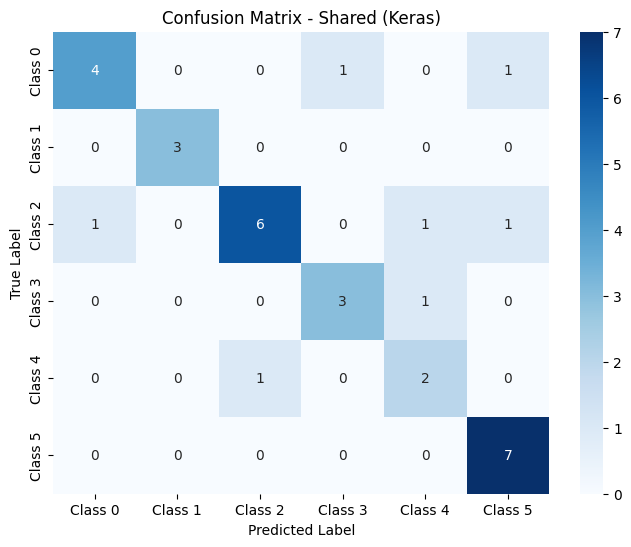

In [32]:
# Keras
keras_preds_probs = keras_model.predict(X_batch, batch_size=batch_size, verbose=0)
keras_preds = np.argmax(keras_preds_probs, axis=1)

# Scratch
scratch_preds = np.argmax(shared_output_data, axis=1)

# Macro F1 Score
macro_f1_keras = f1_score(y_true, keras_preds, average='macro', zero_division=0)
macro_f1_scratch = f1_score(y_true, scratch_preds, average='macro', zero_division=0)

print("\n" + "="*67)
print("PERBANDINGAN KERAS VS SCRATCH (SHARED PARAMETER)")
print("="*67)
print(f"Total Parameter Model  : {keras_model.count_params():,}")
print(f"Macro F1-Score Keras   : {macro_f1_keras:.4f}")
print(f"Macro F1-Score Scratch : {macro_f1_scratch:.4f}")
print("="*67)

# Classification Report
print("\n" + "-" * 67)
print("CLASSIFICATION REPORT")
print("-" * 67)

target_labels = [f"Class {i}" for i in range(num_classes)]
print(
    classification_report(
        y_true,
        scratch_preds,
        labels=range(num_classes),
        target_names=target_labels,
        zero_division=0,
    )
)

target_labels = [f"Class {i}" for i in range(num_classes)]
print(
    classification_report(
        y_true,
        keras_preds,
        labels=range(num_classes),
        target_names=target_labels,
        zero_division=0,
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, scratch_preds, labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_labels,
    yticklabels=target_labels,
)
plt.title("Confusion Matrix - Shared (Scratch)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

cm = confusion_matrix(y_true, keras_preds, labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_labels,
    yticklabels=target_labels,
)
plt.title("Confusion Matrix - Shared (Keras)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Non-shared parameter

In [35]:
weights_path_non_shared = os.path.abspath("saved_models/model_non_shared.weights.h5")

non_shared_model = Model()
non_shared_model.add(AveragePooling2D(pool_size=4, stride=4)) 
non_shared_model.add(LocallyConnected2D(output_channels=16, kernel_size=3, padding=0, activation="relu"))
non_shared_model.add(AveragePooling2D(pool_size=2, stride=2))
non_shared_model.add(Flatten())
non_shared_model.add(Dense(32, activation="relu"))
non_shared_model.add(Dense(num_classes, activation="softmax"))

non_shared_model.build(X_batch.shape)

if os.path.exists(weights_path_non_shared):
    keras_input = layers.Input(shape=input_shape)
    x = layers.AveragePooling2D(4)(keras_input)
    x = layers.LocallyConnected2D(16, 3, padding="valid", activation="relu")(x)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    keras_output = layers.Dense(num_classes, activation="softmax")(x)
    keras_model_ns = models.Model(inputs=keras_input, outputs=keras_output)
    
    keras_model_ns.load_weights(weights_path_non_shared)
    load_keras_weights(non_shared_model, keras_model_ns)
    print("Bobot Keras model Non-Shared berhasil dimuat dan ditransfer.")

start_time = time.time()
batch_size_ns = 1 
outputs_list_ns = []

for i in range(0, len(X_batch), batch_size_ns):
    X_mini = X_batch[i : i + batch_size_ns]
    out_mini = non_shared_model.forward(X_mini)
    
    arr_data = out_mini.data if hasattr(out_mini, 'data') else out_mini.value
    outputs_list_ns.append(arr_data)
    
    del out_mini
    gc.collect()

non_shared_output_data = np.vstack(outputs_list_ns)
non_shared_duration = time.time() - start_time
print(f"Forward pass non-shared selesai dalam {non_shared_duration:.4f} detik.")

del non_shared_model
if "keras_model_ns" in locals():
    del keras_model_ns
gc.collect()

Forward pass non-shared selesai dalam 22.2303 detik.


0


-------------------------------------------------------------------
CLASSIFICATION REPORT (NON-SHARED - RANDOM WEIGHTS)
-------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         6
     Class 1       0.00      0.00      0.00         3
     Class 2       0.00      0.00      0.00         9
     Class 3       0.00      0.00      0.00         4
     Class 4       0.00      0.00      0.00         3
     Class 5       0.20      0.86      0.32         7

    accuracy                           0.19        32
   macro avg       0.03      0.14      0.05        32
weighted avg       0.04      0.19      0.07        32



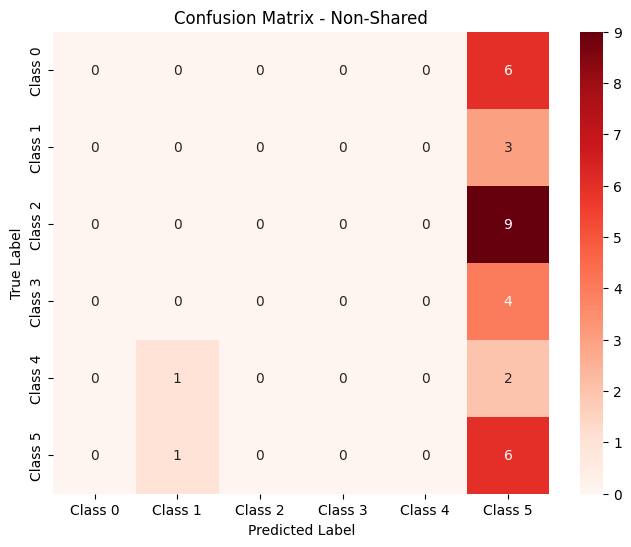

In [34]:
y_pred_probs = non_shared_output_data
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n" + "-" * 67)
print("CLASSIFICATION REPORT (NON-SHARED - RANDOM WEIGHTS)")
print("-" * 67)

target_labels = [f"Class {i}" for i in range(num_classes)]
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(num_classes),
        target_names=target_labels,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds", 
    xticklabels=target_labels,
    yticklabels=target_labels,
)
plt.title("Confusion Matrix - Non-Shared")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()